In [ ]:

from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/datasets/GlobalWeatherRepository.csv'
CLEANED_PATH = '/content/drive/MyDrive/datasets/GlobalWeatherRepository_cleaned.csv'


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 100)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv(DATA_PATH)

print("shape:", df.shape)
display(df.head())
display(df.tail())
df.info()
display(df.describe(include='all').transpose())


shape: (100359, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
100354,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,1760430600,2025-10-14 04:30,26.3,79.3,Partly cloudy,2.2,3.6,175,S,1009.0,29.80,0.00,0.00,79,50,30.5,86.9,10.0,6.0,0.0,3.3,5.3,1125.85,60.0,12.55,4.65,13.45,14.85,1,2,06:16 AM,06:10 PM,12:34 AM,01:39 PM,Waning Crescent,46
100355,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,1760429700,2025-10-14 15:15,28.3,82.9,Moderate rain,8.1,13.0,127,SE,1010.0,29.83,0.43,0.02,84,75,31.4,88.5,10.0,6.0,3.3,13.0,21.0,577.85,34.0,23.25,18.95,22.55,22.65,2,2,05:52 AM,05:34 PM,No moonrise,01:06 PM,Last Quarter,51
100356,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,1760429700,2025-10-14 11:15,19.0,66.3,Sunny,5.1,8.3,4,N,1018.0,30.06,0.00,0.00,19,0,19.0,66.3,10.0,6.0,11.0,5.9,9.5,128.85,94.0,1.65,4.45,12.65,30.75,1,2,05:55 AM,05:44 PM,No moonrise,01:09 PM,Waning Crescent,49
100357,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,1760429700,2025-10-14 10:15,30.1,86.2,Sunny,11.9,19.1,78,ENE,1013.0,29.92,0.00,0.00,25,8,28.5,83.3,10.0,6.0,7.6,13.6,22.0,188.85,95.0,1.45,1.85,15.45,15.95,1,2,05:41 AM,06:06 PM,12:51 AM,12:16 PM,Waning Crescent,48
100358,Zimbabwe,Harare,-17.8178,31.0447,Africa/Harare,1760429700,2025-10-14 10:15,27.3,81.1,Sunny,8.5,13.7,66,ENE,1016.0,29.99,0.00,0.00,32,17,26.5,79.7,10.0,6.0,7.6,9.8,15.7,256.85,117.0,2.55,1.65,24.15,24.95,2,3,05:28 AM,05:56 PM,12:44 AM,12:00 PM,Waning Crescent,48


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100359 entries, 0 to 100358
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       100359 non-null  object 
 1   location_name                 100359 non-null  object 
 2   latitude                      100359 non-null  float64
 3   longitude                     100359 non-null  float64
 4   timezone                      100359 non-null  object 
 5   last_updated_epoch            100359 non-null  int64  
 6   last_updated                  100359 non-null  object 
 7   temperature_celsius           100359 non-null  float64
 8   temperature_fahrenheit        100359 non-null  float64
 9   condition_text                100359 non-null  object 
 10  wind_mph                      100359 non-null  float64
 11  wind_kph                      100359 non-null  float64
 12  wind_degree                   100359 non-nul

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,100359,211,Bulgaria,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_name,100359,254,Kabul,516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,100359.0,NaN,NaN,NaN,19.153047,24.453078,-41.3,3.75,17.25,40.4,64.15
longitude,100359.0,NaN,NaN,NaN,22.092539,65.814675,-175.2,-6.8361,23.3167,50.58,179.22
timezone,100359,197,Asia/Bangkok,1956,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_updated_epoch,100359.0,NaN,NaN,NaN,1738190870.594565,12895175.154301,1715849100.0,1727084700.0,1738232100.0,1749372300.0,1760430600.0
last_updated,100359,17044,2025-04-14 11:30,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature_celsius,100359.0,NaN,NaN,NaN,22.73908,8.864877,-24.9,18.1,24.8,28.3,49.2
temperature_fahrenheit,100359.0,NaN,NaN,NaN,72.932103,15.956594,-12.8,64.6,76.7,82.9,120.6
condition_text,100359,47,Partly cloudy,31148,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean()*100).round(2).sort_values(ascending=False)
pd.concat([missing, missing_percent], axis=1, keys=['missing_count','missing_pct']).head(50)

print("duplicate rows (exact):", df.duplicated().sum())

for col in ['country','location_name'][:5]:
    if col in df.columns:
        print(f"--- {col} ---")
        print(df[col].value_counts(dropna=False).head(10))


duplicate rows (exact): 0
--- country ---
country
Bulgaria      1114
Indonesia     1033
Iran          1030
Sudan         1030
Thailand      1029
Turkey        1029
Bolivia       1023
Belgium       1008
Madagascar     974
Vietnam        927
Name: count, dtype: int64
--- location_name ---
location_name
Kabul               516
Tirana              516
Andorra La Vella    516
Luanda              516
Manama              516
Yerevan             516
Gaborone            516
Bujumbura           516
Sarajevo            516
Praia               516
Name: count, dtype: int64


In [ ]:
df.dtypes

categorical_cols = df.select_dtypes(include=['object','category']).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Categorical:", len(categorical_cols), categorical_cols[:20])
print("Numeric:", len(numeric_cols), numeric_cols[:40])


Categorical: 11 ['country', 'location_name', 'timezone', 'last_updated', 'condition_text', 'wind_direction', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase']
Numeric: 30 ['latitude', 'longitude', 'last_updated_epoch', 'temperature_celsius', 'temperature_fahrenheit', 'wind_mph', 'wind_kph', 'wind_degree', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'moon_illumination']


In [ ]:
date_candidates = [c for c in df.columns if any(k in c.lower() for k in ['date','time','timestamp','last_updated','datetime'])]
date_candidates

for c in date_candidates:
    try:
        df[c] = pd.to_datetime(df[c], errors='coerce', infer_datetime_format=True)
        print(c, "-> datetime, NaT count:", df[c].isna().sum())
    except Exception as e:
        print("failed parsing", c, e)

!pip install timezonefinder

from timezonefinder import TimezoneFinder

tf = TimezoneFinder()

def get_timezone(lat, lon):
    try:
        tz = tf.timezone_at(lat=lat, lng=lon)
        return tz if tz else 'Unknown'
    except:
        return 'Unknown'

# Apply to your DataFrame
df['timezone'] = df.apply(lambda row: get_timezone(row['latitude'], row['longitude']), axis=1)

# View updated results
print(df[['latitude', 'longitude', 'timezone']].head())




for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object','string','category']).columns.tolist()


/tmp/ipython-input-1408963149.py:6: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[c] = pd.to_datetime(df[c], errors='coerce', infer_datetime_format=True)
/tmp/ipython-input-1408963149.py:6: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[c] = pd.to_datetime(df[c], errors='coerce', infer_datetime_format=True)
/tmp/ipython-input-1408963149.py:6: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-

timezone -> datetime, NaT count: 100359
last_updated_epoch -> datetime, NaT count: 0
last_updated -> datetime, NaT count: 0
date -> datetime, NaT count: 0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.2/28.2 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.6 MB/s eta 0:00:00
      latitude  longitude      timezone
3265     51.25       3.63  Europe/Paris
3460     51.25       3.63  Europe/Paris
4045     51.25       3.63  Europe/Paris
4240     51.25       3.63  Europe/Paris
5408     51.25       3.63  Europe/Paris


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
temp_cols = [c for c in df.columns if 'temp' in c.lower() or 'temperature' in c.lower()]
temp_cols

def convert_f_to_c(series):
    return (series - 32) * 5.0/9.0

for c in temp_cols:
    s = pd.to_numeric(df[c], errors='coerce').dropna()
    if s.empty:
        print(c, "no numeric data")
        continue
    max_val = s.max()
    mean_val = s.mean()
    decision = "assume_C"
    if max_val > 60 or mean_val > 40:
        df[c + '_orig_f'] = df[c]
        df[c] = convert_f_to_c(df[c])
        decision = "converted_F_to_C"
    print(c, "max:", max_val, "mean:", mean_val, "=>", decision)



temperature_celsius max: 49.2 mean: 22.739079703863133 => assume_C
temperature_fahrenheit max: 49.22222222222222 mean: 22.74005708395748 => assume_C
temperature_fahrenheit_orig_f max: 49.22222222222222 mean: 22.74005708395748 => assume_C
temp_bin no numeric data
temp_7d_mean max: 47.7 mean: 22.752760743692047 => assume_C
temperature_fahrenheit_orig_f_orig_f max: 49.22222222222222 mean: 22.74005708395748 => assume_C
temperature_fahrenheit_orig_f_orig_f_orig_f max: 49.22222222222222 mean: 22.74005708395748 => assume_C
temperature_fahrenheit_orig_f_orig_f_orig_f_orig_f max: 120.6 mean: 72.93210275112347 => converted_F_to_C


,count,mean,std,min,25%,50%,75%,max
latitude,100359.0,1.915305e+01,2.445308e+01,-4.130000e+01,3.750000e+00,1.725000e+01,4.040000e+01,6.415000e+01
longitude,100359.0,2.209254e+01,6.581468e+01,-1.752000e+02,-6.836100e+00,2.331670e+01,5.058000e+01,1.792200e+02
last_updated_epoch,100359.0,1.738191e+09,1.289518e+07,1.715849e+09,1.727085e+09,1.738232e+09,1.749372e+09,1.760431e+09
temperature_celsius,100359.0,2.273908e+01,8.864877e+00,-2.490000e+01,1.810000e+01,2.480000e+01,2.830000e+01,4.920000e+01
temperature_fahrenheit,100359.0,2.274006e+01,8.864774e+00,-2.488889e+01,1.811111e+01,2.483333e+01,2.827778e+01,4.922222e+01
wind_mph,100359.0,8.213591e+00,7.809938e+00,2.200000e+00,4.000000e+00,6.900000e+00,1.120000e+01,1.841200e+03
wind_kph,100359.0,1.322185e+01,1.256642e+01,3.600000e+00,6.500000e+00,1.120000e+01,1.800000e+01,2.963200e+03
wind_degree,100359.0,1.708874e+02,1.027448e+02,1.000000e+00,8.300000e+01,1.650000e+02,2.560000e+02,3.600000e+02
pressure_mb,100359.0,1.014010e+03,1.127178e+01,9.470000e+02,1.010000e+03,1.013000e+03,1.018000e+03,3.006000e+03
pressure_in,100359.0,2.994306e+01,3.328079e-01,2.796000e+01,2.983000e+01,2.992000e+01,3.005000e+01,8.877000e+01


,mean,median,std,min,max,skew,kurt
latitude,1.915305e+01,1.725000e+01,2.445308e+01,-4.130000e+01,6.415000e+01,-0.305723,-0.745894
longitude,2.209254e+01,2.331670e+01,6.581468e+01,-1.752000e+02,1.792200e+02,0.003557,0.333249
last_updated_epoch,1.738191e+09,1.738232e+09,1.289518e+07,1.715849e+09,1.760431e+09,-0.008771,-1.194177
temperature_celsius,2.273908e+01,2.480000e+01,8.864877e+00,-2.490000e+01,4.920000e+01,-0.789301,0.876880
temperature_fahrenheit,2.274006e+01,2.483333e+01,8.864774e+00,-2.488889e+01,4.922222e+01,-0.789248,0.876718
wind_mph,8.213591e+00,6.900000e+00,7.809938e+00,2.200000e+00,1.841200e+03,129.359716,30237.662012
wind_kph,1.322185e+01,1.120000e+01,1.256642e+01,3.600000e+00,2.963200e+03,129.445335,30264.271561
wind_degree,1.708874e+02,1.650000e+02,1.027448e+02,1.000000e+00,3.600000e+02,0.151584,-1.165322
pressure_mb,1.014010e+03,1.013000e+03,1.127178e+01,9.470000e+02,3.006000e+03,109.532432,19320.484331
pressure_in,2.994306e+01,2.992000e+01,3.328079e-01,2.796000e+01,8.877000e+01,109.594894,19334.327061


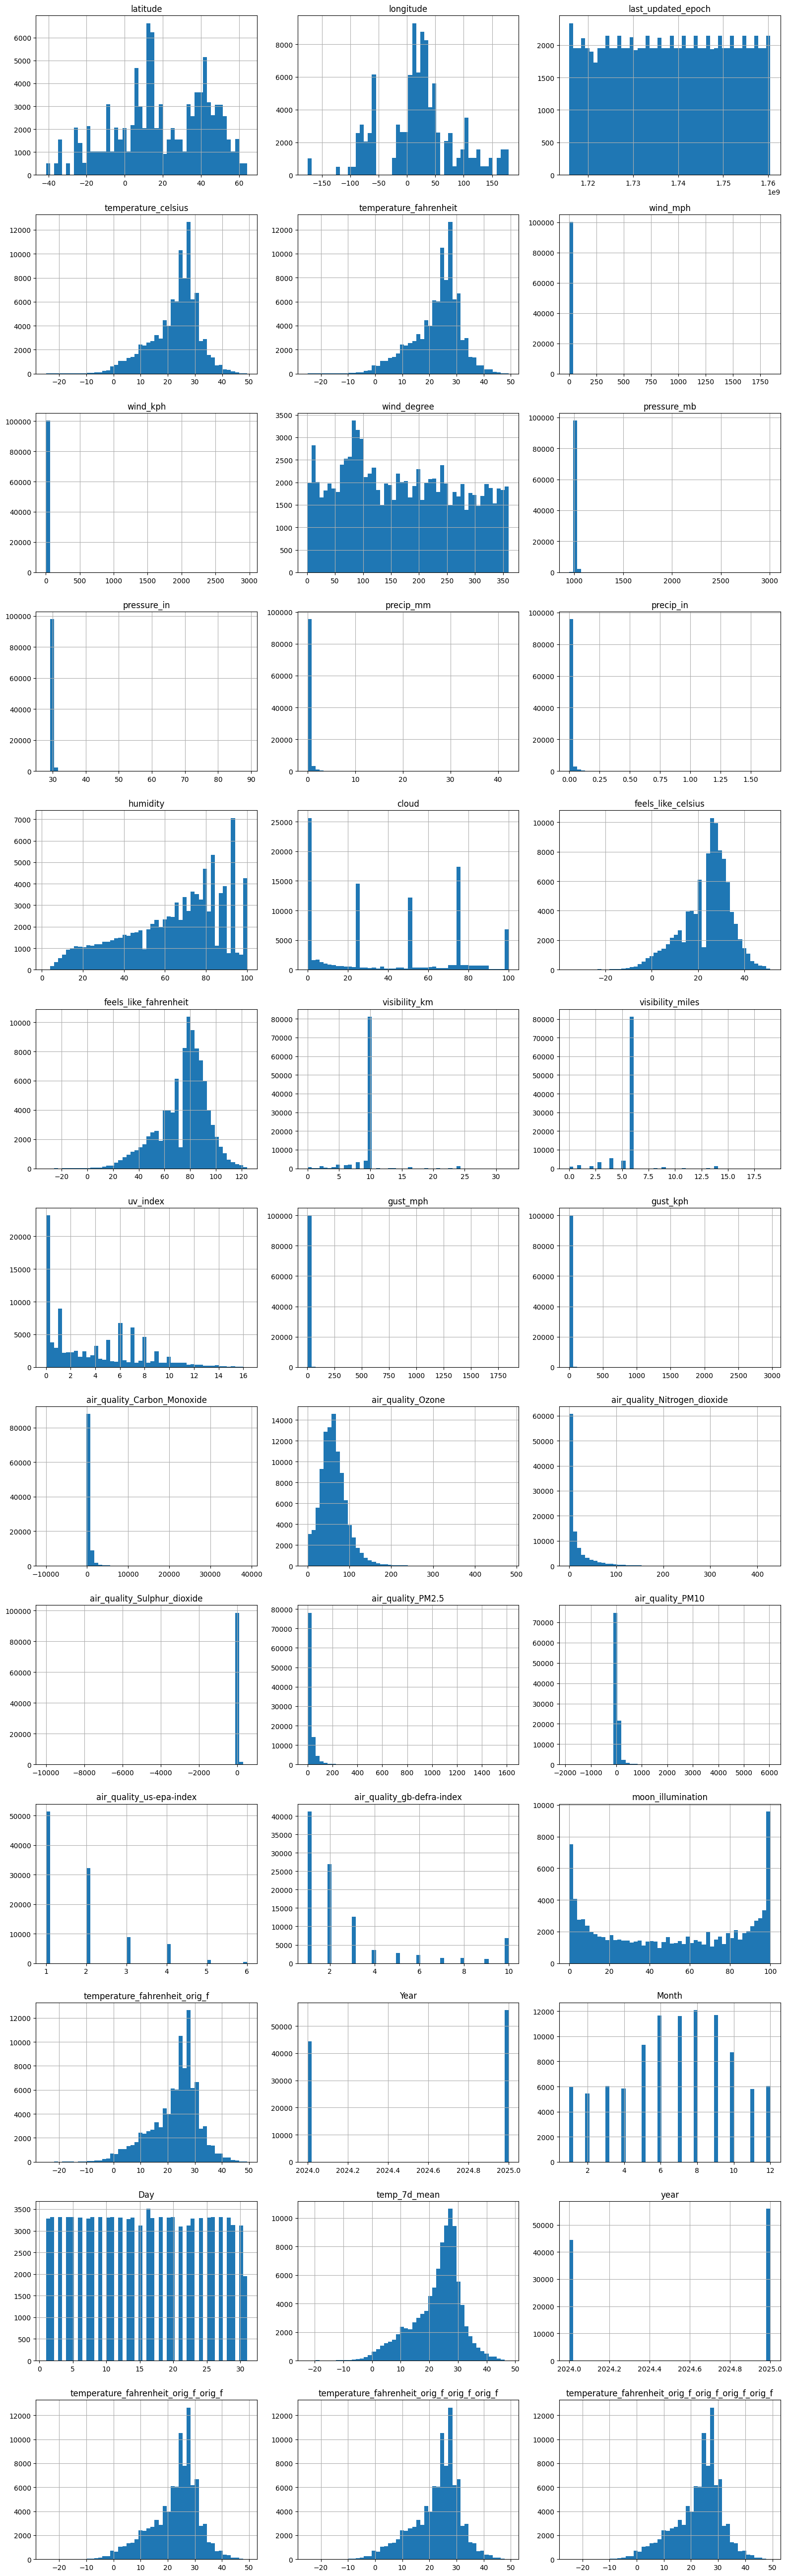

In [ ]:
display(df[numeric_cols].describe().transpose())

stats_df = df[numeric_cols].agg(['mean','median','std','min','max','skew','kurt']).transpose()
display(stats_df)

import math
cols_to_plot = numeric_cols
n = len(cols_to_plot)
cols_per_row = 3
rows = math.ceil(n/cols_per_row)
plt.figure(figsize=(16,4*rows))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(rows, cols_per_row, i)
    df[col].hist(bins=50)
    plt.title(col)
plt.tight_layout()


<Axes: >

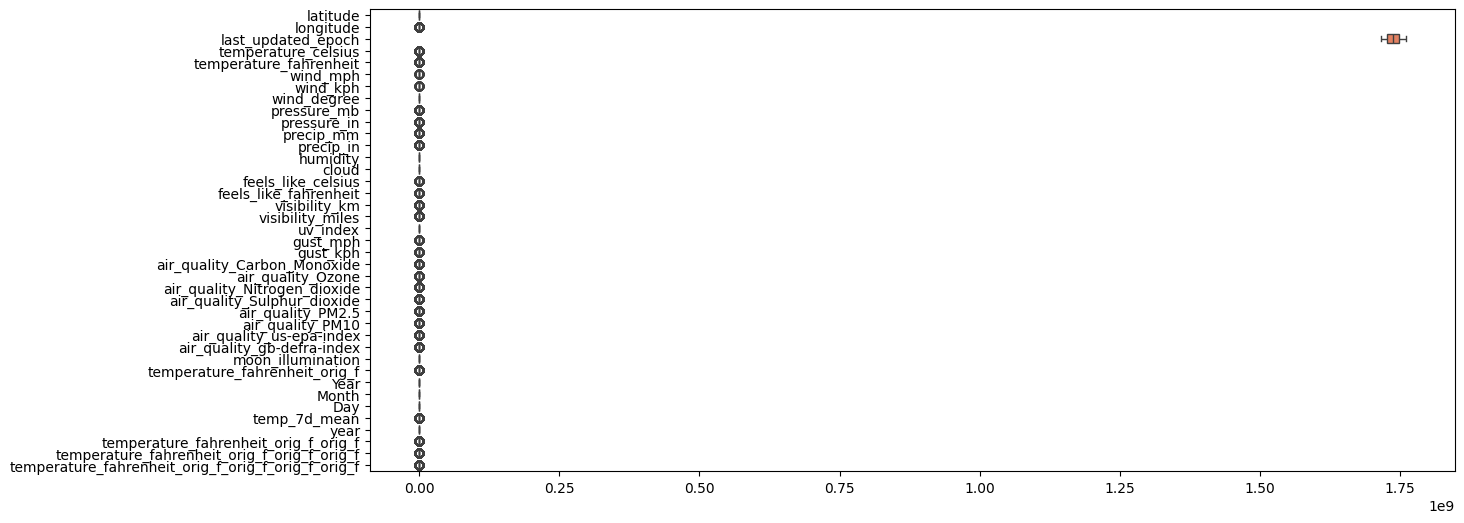

In [ ]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df[numeric_cols].sample(frac=0.05, random_state=1), orient='h')

In [ ]:
for c in categorical_cols[:6]:
    print("=== ", c, "===")
    display(df[c].value_counts(dropna=False).head(20))


===  country ===


,count
country,
Bulgaria,1114
Indonesia,1033
Iran,1030
Sudan,1030
Thailand,1029
Turkey,1029
Bolivia,1023
Belgium,1008
Madagascar,974


===  location_name ===


,count
location_name,
Abu Dhabi,516
Abuja,516
Accra,516
Antananarivo,516
Andorra La Vella,516
Amman,516
Asmara,516
Baghdad,516
Bern,516


===  timezone ===


...

,count
condition_text,
Partly cloudy,31148
Sunny,31000
Patchy rain nearby,8331
Partly Cloudy,5490
Overcast,4820
Clear,4425
Mist,3165
Light rain,2992
Light rain shower,2412


===  wind_direction ===


,count
wind_direction,
E,9483
ENE,7908
ESE,7016
N,6550
S,6214
NNE,6177
WSW,6176
SW,6130
SSW,6125


===  sunrise ===


,count
sunrise,
05:56 AM,1133
05:57 AM,1128
05:55 AM,1120
05:54 AM,1090
06:17 AM,1053
05:58 AM,1032
06:10 AM,1030
05:49 AM,1016
06:21 AM,1013


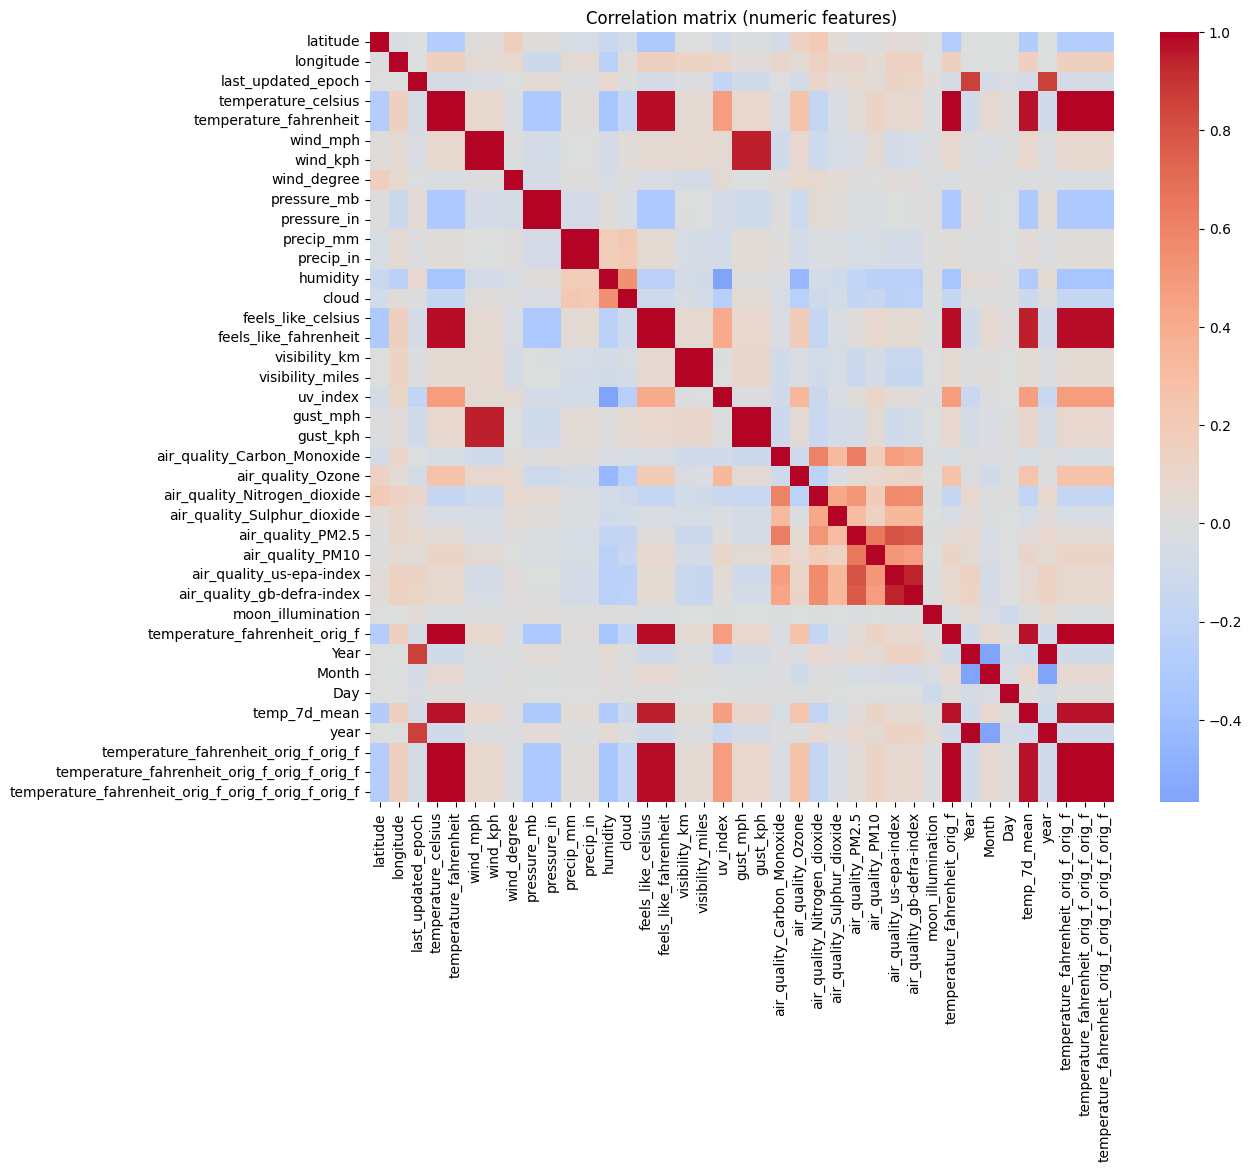

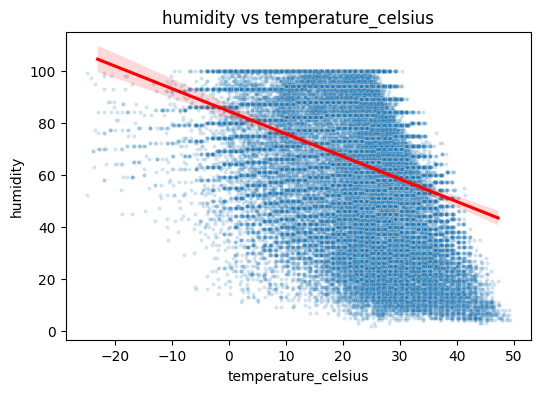

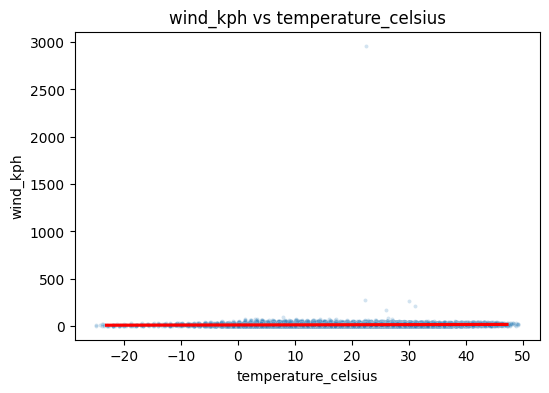

In [ ]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation matrix (numeric features)")
plt.show()
pairs = [('temperature_celsius','humidity'), ('temperature_celsius','wind_kph')]  # edit as appropriate
for x,y in pairs:
    if x in df.columns and y in df.columns:
        plt.figure(figsize=(6,4))
        sns.scatterplot(data=df, x=x, y=y, alpha=0.2, s=8)
        sns.regplot(data=df.sample(n=2000, random_state=1), x=x, y=y, scatter=False, color='red')  # sample for regression line
        plt.title(f"{y} vs {x}")
        plt.show()


In [ ]:
def iqr_outlier_bounds(s):
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5*IQR, Q3 + 1.5*IQR

outlier_info = {}
for c in numeric_cols:
    s = df[c].dropna()
    if s.empty: continue
    low, high = iqr_outlier_bounds(s)
    out_count = ((s < low) | (s > high)).sum()
    outlier_info[c] = {'low': low, 'high': high, 'outliers': int(out_count)}
pd.DataFrame(outlier_info).T.sort_values('outliers', ascending=False).head(20)


,low,high,outliers
visibility_km,10.000000,10.000000,19250.0
visibility_miles,6.000000,6.000000,19117.0
precip_mm,-0.045000,0.075000,19019.0
precip_in,0.000000,0.000000,15933.0
air_quality_Sulphur_dioxide,-11.347500,21.312500,13546.0
air_quality_Nitrogen_dioxide,-23.667500,42.912500,11043.0
air_quality_gb-defra-index,-2.000000,6.000000,10785.0
air_quality_PM10,-41.125000,97.155000,10697.0
air_quality_Carbon_Monoxide,-170.550000,907.450000,9078.0
air_quality_PM2.5,-25.900000,62.900000,8428.0


In [ ]:
missing = (df.isnull().mean()*100).round(2).sort_values(ascending=False)
display(missing.head(60))

num_impute_cols = numeric_cols
for c in num_impute_cols:
    med = df[c].median()
    df[c] = df[c].fillna(med)

for c in categorical_cols:
    if df[c].isnull().any():
        mode = df[c].mode(dropna=True)
        fill_val = mode[0] if not mode.empty else 'Unknown'
        df[c] = df[c].fillna(fill_val)


,0
country,0.0
location_name,0.0
latitude,0.0
longitude,0.0
timezone,0.0
last_updated_epoch,0.0
last_updated,0.0
temperature_celsius,0.0
temperature_fahrenheit,0.0
condition_text,0.0


In [ ]:
date_col = 'last_updated'
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df['Year'] = df[date_col].dt.year
df['Month'] = df[date_col].dt.month
df['Day'] = df[date_col].dt.day

def month_to_season(m):
    if m in [12,1,2]: return 'Winter'
    if m in [3,4,5]: return 'Spring'
    if m in [6,7,8]: return 'Summer'
    return 'Autumn'
df['Season'] = df['Month'].apply(lambda x: month_to_season(x) if not pd.isna(x) else np.nan)

if 'temperature_celsius' in df.columns:
    df['temp_bin'] = pd.cut(df['temperature_celsius'], bins=[-50,0,10,20,30,40,100], labels=['<-0','0-10','10-20','20-30','30-40','40+'])


In [ ]:
df = df.sort_values(by=[ 'location_name', date_col ])
df['temp_7d_mean'] = df.groupby('location_name')['temperature_celsius'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())


In [ ]:
df = df.dropna(subset=['latitude','longitude'])

df = df[(df['latitude'].between(-90,90)) & (df['longitude'].between(-180,180))]


In [ ]:
df.columns


Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination',
       'temperature_fahrenheit_orig_f', 'Year', 'Month', 'Day', 'Season',
       'temp_bin', 'temp_7d_mean', 'date', 'year_month', 'year',
       'temperature_fahrenheit_orig_f_orig_f',
       'temperature_

In [ ]:
# Combine Year, Month, and Day columns into a single datetime column
df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])

# Now define the column for grouping
date_col = 'date'
df[date_col] = pd.to_datetime(df[date_col])


agg_cols = {
    'temperature_celsius': ['mean', 'median', 'min', 'max', 'std'],
    'precip_mm': ['sum', 'mean', 'max'],
    'humidity': ['mean']
}

df['year_month'] = df[date_col].dt.to_period('M')

monthly = df.groupby(['year_month', 'location_name']).agg(agg_cols)
monthly.columns = ['_'.join(col) for col in monthly.columns]
monthly = monthly.reset_index()

print("Monthly Aggregation Done!")
display(monthly.head())

df['year'] = df[date_col].dt.year

yearly = df.groupby(['year', 'location_name']).agg(agg_cols)
yearly.columns = ['_'.join(col) for col in yearly.columns]
yearly = yearly.reset_index()

print("Yearly Aggregation Done!")
display(yearly.head())





Monthly Aggregation Done!


,year_month,location_name,temperature_celsius_mean,temperature_celsius_median,temperature_celsius_min,temperature_celsius_max,temperature_celsius_std,precip_mm_sum,precip_mm_mean,precip_mm_max,humidity_mean
0,2024-05,'S Gravenjansdijk,16.000000,16.0,16.0,16.0,NaN,0.29,0.290000,0.29,82.000000
1,2024-05,'S Gravenstaffel,15.562500,15.5,13.0,19.0,1.504161,3.02,0.188750,0.87,80.500000
2,2024-05,Abu Dhabi,35.352941,36.0,32.0,39.0,2.206274,0.00,0.000000,0.00,39.235294
3,2024-05,Abuja,33.323529,33.0,29.2,39.4,2.465139,0.00,0.000000,0.00,54.588235
4,2024-05,Accra,30.358824,30.0,28.0,33.0,1.388821,1.78,0.104706,1.54,72.176471


Yearly Aggregation Done!


,year,location_name,temperature_celsius_mean,temperature_celsius_median,temperature_celsius_min,temperature_celsius_max,temperature_celsius_std,precip_mm_sum,precip_mm_mean,precip_mm_max,humidity_mean
0,2024,'S Gravenjansdijk,15.659799,16.10,1.1,32.2,7.121655,23.15,0.116332,1.94,73.773869
1,2024,'S Gravenjansdyk,16.341667,17.05,12.1,18.6,2.091741,1.93,0.160833,1.70,67.583333
2,2024,'S Gravenstaffel,15.562500,15.50,13.0,19.0,1.504161,3.02,0.188750,0.87,80.500000
3,2024,-Kingdom,29.700000,29.70,29.7,29.7,NaN,0.00,0.000000,0.00,24.000000
4,2024,Abu Dhabi,33.939738,34.90,20.4,44.1,5.505232,0.09,0.000393,0.05,49.318777


In [ ]:
# Save the cleaned full dataset
df.to_csv(CLEANED_PATH, index=False)
print("Saved cleaned dataset to:", CLEANED_PATH)

# Save summary aggregates if needed
monthly_path = '/content/drive/MyDrive/datasets/GlobalWeatherRepository_monthly.csv'
monthly.to_csv(monthly_path, index=False)
print("Saved monthly aggregates to:", monthly_path)



Saved cleaned dataset to: /content/drive/MyDrive/datasets/GlobalWeatherRepository_cleaned.csv
Saved monthly aggregates to: /content/drive/MyDrive/datasets/GlobalWeatherRepository_monthly.csv


In [ ]:
monthly = df.groupby(['year_month', 'location_name']).agg(agg_cols)



In [ ]:
monthly.columns


MultiIndex([('temperature_celsius',   'mean'),
            ('temperature_celsius', 'median'),
            ('temperature_celsius',    'min'),
            ('temperature_celsius',    'max'),
            ('temperature_celsius',    'std'),
            (          'precip_mm',    'sum'),
            (          'precip_mm',   'mean'),
            (          'precip_mm',    'max'),
            (           'humidity',   'mean')],
           )

In [ ]:
# Reset index to bring 'year_month' and 'location_name' back as columns
monthly = monthly.reset_index()

# Flatten MultiIndex columns into single level
monthly.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in monthly.columns]

# Show the fixed columns
print(monthly.columns)
monthly.head()


Index(['year_month_', 'location_name_', 'temperature_celsius_mean',
       'temperature_celsius_median', 'temperature_celsius_min',
       'temperature_celsius_max', 'temperature_celsius_std', 'precip_mm_sum',
       'precip_mm_mean', 'precip_mm_max', 'humidity_mean'],
      dtype='object')


,year_month_,location_name_,temperature_celsius_mean,temperature_celsius_median,temperature_celsius_min,temperature_celsius_max,temperature_celsius_std,precip_mm_sum,precip_mm_mean,precip_mm_max,humidity_mean
0,2024-05,'S Gravenjansdijk,16.000000,16.0,16.0,16.0,NaN,0.29,0.290000,0.29,82.000000
1,2024-05,'S Gravenstaffel,15.562500,15.5,13.0,19.0,1.504161,3.02,0.188750,0.87,80.500000
2,2024-05,Abu Dhabi,35.352941,36.0,32.0,39.0,2.206274,0.00,0.000000,0.00,39.235294
3,2024-05,Abuja,33.323529,33.0,29.2,39.4,2.465139,0.00,0.000000,0.00,54.588235
4,2024-05,Accra,30.358824,30.0,28.0,33.0,1.388821,1.78,0.104706,1.54,72.176471


In [ ]:
for c in categorical_cols:
    if df[c].isna().sum() > 0:
        mode = df[c].mode()[0]
        df[c] = df[c].fillna(mode)


In [ ]:
df = df.drop_duplicates()


In [ ]:
if 'last_updated' in df.columns:
    df['Year'] = df['last_updated'].dt.year
    df['Month'] = df['last_updated'].dt.month
    df['Season'] = df['Month'].map({12:'Winter',1:'Winter',2:'Winter',
                                    3:'Spring',4:'Spring',5:'Spring',
                                    6:'Summer',7:'Summer',8:'Summer',
                                    9:'Autumn',10:'Autumn',11:'Autumn'})


In [ ]:
df = df[(df['humidity'].between(0,100)) & (df['temperature_celsius'].between(-50,60))]


In [ ]:
monthly_avg = df.groupby(['country','Year','Month'])['temperature_celsius'].mean().reset_index()


In [ ]:
print("Before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

for c in categorical_cols:
    if df[c].isna().sum() > 0:
        mode = df[c].mode()[0]
        df[c] = df[c].fillna(mode)
print("Missing values handled.")

if 'last_updated' in df.columns:
    df['Year'] = df['last_updated'].dt.year
    df['Month'] = df['last_updated'].dt.month
    df['Season'] = df['Month'].map({
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
    })
    print("Added Year, Month, and Season columns.")

if 'humidity' in df.columns and 'temperature_celsius' in df.columns:
    df = df[(df['humidity'].between(0, 100)) &
            (df['temperature_celsius'].between(-50, 60))]
    print("Filtered unrealistic humidity/temperature values.")

if {'country', 'Year', 'Month', 'temperature_celsius'}.issubset(df.columns):
    monthly_avg = (
        df.groupby(['country', 'Year', 'Month'])['temperature_celsius']
        .mean()
        .reset_index()
        .rename(columns={'temperature_celsius': 'avg_temp_c'})
    )
    print("Created monthly average temperature table.")
else:
    monthly_avg = df.copy()  # fallback

clean_path = '/content/drive/MyDrive/datasets/GlobalWeatherRepository_cleaned.csv'
df.to_csv(clean_path, index=False)
print(f"Cleaned dataset saved successfully at: {clean_path}")

monthly_avg.to_csv('/content/drive/MyDrive/datasets/GlobalWeatherRepository_monthly_avg.csv', index=False)
print("Monthly aggregated dataset saved successfully!")

print("Final shape:", df.shape)
df.head()


Before removing duplicates: (100359, 55)
After removing duplicates: (100359, 55)
Missing values handled.
Added Year, Month, and Season columns.
Filtered unrealistic humidity/temperature values.
Created monthly average temperature table.
Cleaned dataset saved successfully at: /content/drive/MyDrive/datasets/GlobalWeatherRepository_cleaned.csv
Monthly aggregated dataset saved successfully!
Final shape: (100359, 55)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,temperature_fahrenheit_orig_f,Year,Month,Day,Season,temp_bin,temp_7d_mean,date,year_month,year,temperature_fahrenheit_orig_f_orig_f,temperature_fahrenheit_orig_f_orig_f_orig_f,temperature_fahrenheit_orig_f_orig_f_orig_f_orig_f,temperature_fahrenheit_orig_f_orig_f_orig_f_orig_f_orig_f
3265,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Paris,1717164900,2024-05-31 16:15:00,16.0,16.000000,Moderate rain,17.4,28.1,20,NNE,1014.0,29.94,0.29,0.01,82,50,16.0,60.8,10.0,6.0,4.0,22.5,36.3,186.9,87.3,2.7,1.3,2.2,3.4,1,1,05:36 AM,09:52 PM,02:59 AM,02:09 PM,Waning Crescent,47,16.000000,2024,5,31,Spring,10-20,16.000000,2024-05-31,2024-05,2024,16.000000,16.000000,16.000000,60.8
3460,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Paris,1717252200,2024-06-01 16:30:00,16.0,16.000000,Overcast,9.4,15.1,330,NNW,1019.0,30.09,0.01,0.00,88,100,16.0,60.8,10.0,6.0,4.0,24.1,38.7,186.9,88.7,2.2,1.8,6.5,19.6,1,1,05:35 AM,09:53 PM,03:12 AM,03:34 PM,Waning Crescent,35,16.000000,2024,6,1,Summer,10-20,16.000000,2024-06-01,2024-06,2024,16.000000,16.000000,16.000000,60.8
4045,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Paris,1717510500,2024-06-04 16:15:00,18.0,18.000000,Partly cloudy,16.1,25.9,270,W,1011.0,29.85,0.06,0.00,77,25,18.0,64.4,10.0,6.0,4.0,20.6,33.1,185.3,83.0,5.1,2.2,5.7,6.0,1,1,05:33 AM,09:56 PM,03:56 AM,07:57 PM,Waning Crescent,8,18.000000,2024,6,4,Summer,10-20,16.666667,2024-06-04,2024-06,2024,18.000000,18.000000,18.000000,64.4
4240,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Paris,1717596900,2024-06-05 16:15:00,15.0,15.000000,Partly cloudy,6.9,11.2,330,NNW,1015.0,29.97,0.00,0.00,44,25,13.7,56.6,10.0,6.0,4.0,14.7,23.6,186.9,94.4,1.9,1.4,1.2,2.4,1,1,05:33 AM,09:56 PM,04:17 AM,09:25 PM,Waning Crescent,3,15.000000,2024,6,5,Summer,10-20,16.250000,2024-06-05,2024-06,2024,15.000000,15.000000,15.000000,59.0
5408,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Paris,1718115300,2024-06-11 16:15:00,15.2,15.222222,Partly cloudy,15.0,24.1,280,W,1017.0,30.03,0.41,0.02,59,75,15.2,59.4,10.0,6.0,3.0,17.5,28.2,178.6,82.3,1.4,0.9,0.5,0.9,1,1,05:30 AM,10:01 PM,10:16 AM,01:31 AM,Waxing Crescent,21,15.222222,2024,6,11,Summer,10-20,16.040000,2024-06-11,2024-06,2024,15.222222,15.222222,15.222222,59.4
